# Bayesian Hierarchical Modeling of Neutralization Data in CovDB

In [1]:
import os
import pandas as pd
import numpy as np
import re
import torch
from collections import defaultdict
from datetime import datetime as dt
import json

from scipy.stats import ttest_ind, f_oneway
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm, trange
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity as KDE

import pyro
import pyro.distributions as dist
import pyro.distributions.constraints as constraints
from pyro.optim import Adam
from pyro.infer import SVI, Trace_ELBO, autoguide

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import colorcet as cc

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/kotzen/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.rcParams["font.family"] = "Times New Roman"

pyro.set_rng_seed(0)
pyro.clear_param_store()

d = torch.float32
torch.set_default_dtype(d)

run_SVI = False
load_date = '2024-10-14'
date = dt.today().strftime('%Y-%m-%d') if run_SVI else load_date

---
## Read in data

In [3]:
def expand_indels(mutations):
    mutations = mutations.split(' + ')
    expanded_mutations = []
    for i, mut in enumerate(mutations):
        match = re.match(r'Δ(\d+)-(\d+)', mut)
        if match:
            mutations.pop(i)
            x, z = int(match.group(1)), int(match.group(2))
            indels = [f'Δ{i}' for i in range(x, z + 1)]
            expanded_mutations += indels
        else:
            expanded_mutations.append(mut)
    return ' + '.join(expanded_mutations)

In [4]:
vp_dir = 'data/CoVDB/vp-studies'
cp_dir = 'data/CoVDB/cp-studies'
vp_csvs = [f for f in os.listdir(vp_dir) if f.endswith('.csv')]
cp_csvs = [f for f in os.listdir(cp_dir) if f.endswith('.csv')]

vp = pd.DataFrame()
for f in vp_csvs:
    temp = pd.read_csv(vp_dir+'/'+f)
    vp = pd.concat([vp, temp])

cp = pd.DataFrame()
for f in cp_csvs:
    temp = pd.read_csv(cp_dir+'/'+f)
    cp = pd.concat([cp, temp])
    
# Create a super-df for all plasma types
vp['Plasma'] = 'Vaccine'; vp['Infection (CP)'] = ''
cp['Plasma'] = 'Convalescent'; cp['Pre-vaccine Infection'] = ''; cp['Vaccine'] = ''; cp['# Shots'] = 0
plasma = pd.concat([vp, cp])

# Clean data
plasma = plasma[plasma['Fold Reduction: Cmp']=='=']
plasma = plasma[plasma['# Results']==1]
plasma = plasma[plasma['Control']=='Wild Type (B.1)']
plasma = plasma[plasma['Host']=='Human']
plasma = plasma[~(plasma['Variant: Mutations']=='(WT)')]
plasma['Vaccine'] = plasma['Vaccine'].apply(lambda x: 'None' if x=='' or pd.isna(x) else x)
plasma['Pre-vaccine Infection'] = plasma['Pre-vaccine Infection'].apply(lambda x: 'None' if x=='' or pd.isna(x) else x)
plasma['Infection (CP)'] = plasma['Infection (CP)'].apply(lambda x: 'None' if x=='' or pd.isna(x) else x)
plasma['Variant: Mutations'] = plasma['Variant: Mutations'].apply(lambda x: expand_indels(x))
plasma = plasma.sort_values(by='Fold Reduction: Median').reset_index(drop=True)

# Convert fold reduction to log fold reduction
plasma['Log fold reduction'] = np.log10(plasma['Fold Reduction: Median'])

# Drop unnecessary columns
plasma_lite = plasma.drop(columns=['Reference', 'Reference: DOI', 'Section', 'Host', 
                                   'Control', 'Control: NT50 Cmp', 'Control: NT50 GeoMean', 'Control: NT50 GSD', 
                                   'Fold Reduction: Cmp', 'Potency: NT50 Cmp', 'Potency: NT50 GeoMean', 'Potency: NT50 GSD',
                                   'Variant', 'Variant: Pos'
                                   ]
                    ).reset_index(
                    ).rename(columns={'index':'ID'})

plasma_lite.head()

,ID,Assay,Pre-vaccine Infection,Vaccine,# Shots,Months,Variant: Mutations,# Results,Fold Reduction: Median,Plasma,Infection (CP),Log fold reduction
0,0,Virus isolate,None,None,0,2-6m,T19R + G142D + Δ156 + Δ157 + L452R + T478K + P...,1,0.1,Convalescent,Delta,-1.00000
1,1,Virus isolate,None,None,0,≥6m,Δ69 + G72R + Δ144 + N501Y + A570D + P681H + T7...,1,0.1,Convalescent,Wild Type,-1.00000
2,2,Virus isolate,None,None,0,≥6m,L18F + T20N + P26S + D138Y + R190S + K417T + E...,1,0.1,Convalescent,Wild Type,-1.00000
3,3,Virus isolate,None,None,0,≥6m,Δ69 + G72R + Δ144 + N501Y + A570D + P681H + T7...,1,0.1,Convalescent,Wild Type,-1.00000
4,4,Virus isolate,None,mRNA,2,2-6m,L5F + T95I + D253G + E484K + A701V,1,0.2,Vaccine,None,-0.69897


---
## QA Data

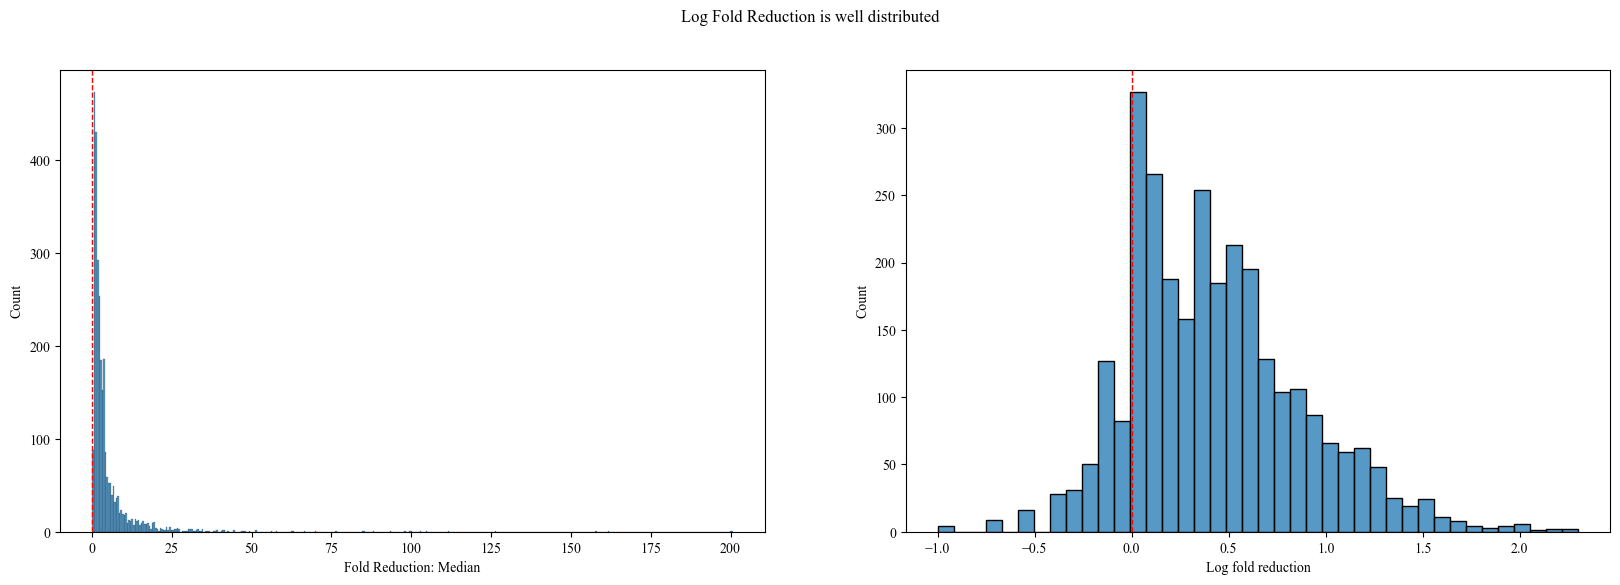

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.histplot(x='Fold Reduction: Median',
             data=plasma_lite,
             ax=axes[0])
sns.histplot(x='Log fold reduction',
             data=plasma_lite,
             ax=axes[1])

for i, ax in enumerate(axes):
    ylim = ax.get_ylim()
    xlim = ax.get_xlim()
    ax.vlines(ylim[0], ylim[1], 1 if i==0 else 0, linestyle='--', color='red', linewidth=1)
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)

fig.suptitle('Log Fold Reduction is well distributed');

fig.savefig('figs/covdb/logfoldreduction_dist.png', dpi=150);

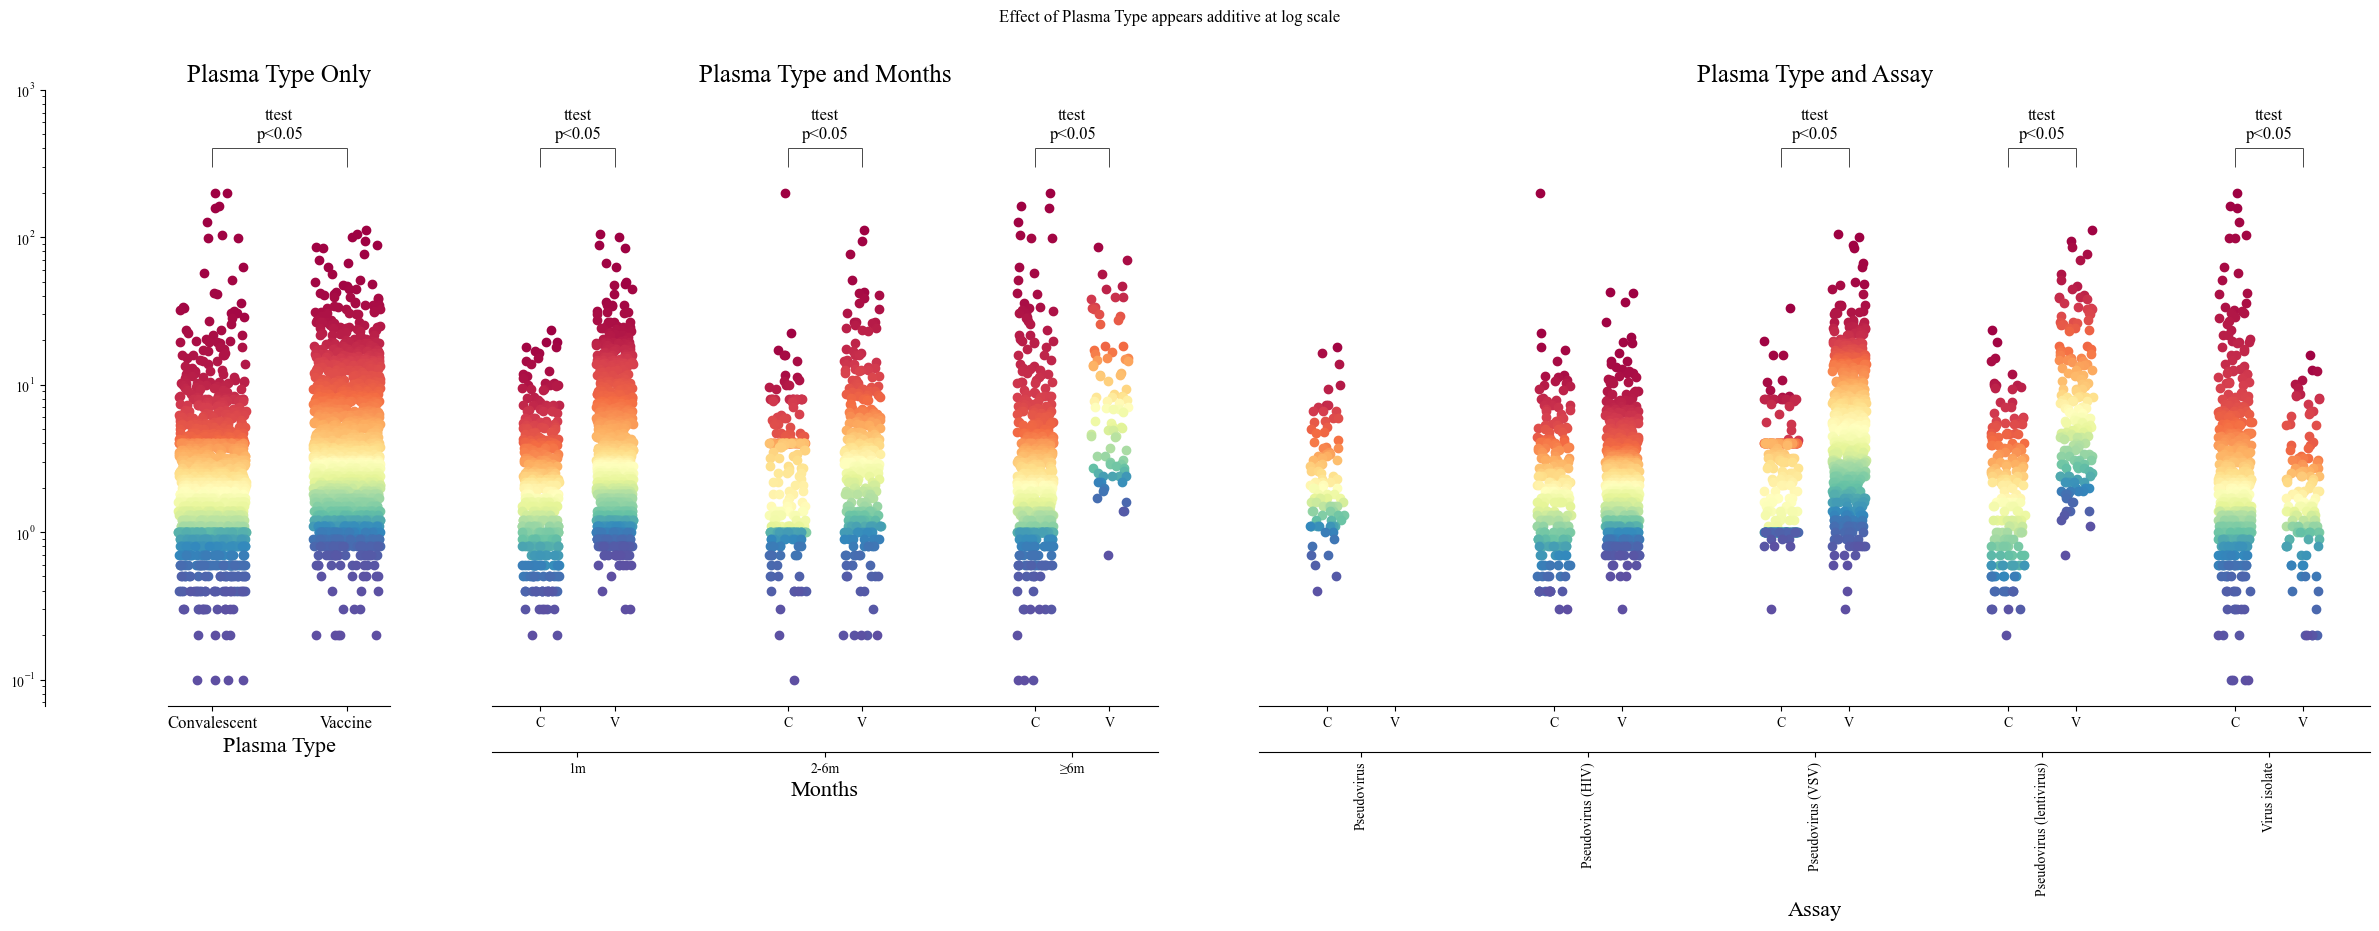

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(30, 8), gridspec_kw={'width_ratios': [0.1, 1, 3, 5]})

jitter_width = 0.15
space = 0.3
palette='Spectral'

miny = plasma_lite['Fold Reduction: Median'].min()
maxy = plasma_lite['Fold Reduction: Median'].max()

# First, just show Plasma types
ax = axes[1]
ax.set_title('Plasma Type Only', fontsize=18)
ax.set_xlabel('Plasma Type', fontsize=16)
s = []
for x, plasma_type in enumerate(sorted(plasma_lite['Plasma'].unique())):
    temp = plasma_lite[plasma_lite['Plasma']==plasma_type].copy()
    temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
    yvals = temp['Fold Reduction: Median']
    xvals = (np.random.random(len(yvals))-0.5) * jitter_width + (x-0.5)*space
    color_map = sns.color_palette(palette, len(temp))
    colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
    for xi,yi,ci in zip (xvals, yvals, colors):
        ax.plot(xi, yi, 'o', color=ci)

    s.append(yvals)
x1, x2 = [-space/2, space/2]
ax.set_xticks([x1, x2])
ax.set_xticklabels(sorted(plasma_lite['Plasma'].unique()), fontsize=12)

stat, p = ttest_ind(s[0], s[1])
if p<0.05:
    ax.vlines([x1, x2], maxy*1.5, maxy*2,
             color='black', linewidth=0.5)
    ax.hlines(maxy*2, x1, x2,
             color='black', linewidth=0.5)
    ax.text((x1+x2)/2, maxy*2.2, 'ttest\np<0.05', fontsize=12, ha='center', va='bottom')
    


# Next, break up by Months
ax = axes[2]
ax.set_title('Plasma Type and Months', fontsize=18)
# ax.set_xlabel('Months', fontsize=16)
xticklabels = []
for x, month in enumerate(sorted(plasma_lite['Months'].unique())):
    x1, x2 = [x-space/2, x+space/2] 
    s = []
    for j, plasma_type in enumerate(sorted(plasma_lite['Plasma'].unique())):
        temp = plasma_lite[(plasma_lite['Months']==month) & (plasma_lite['Plasma']==plasma_type)].copy()
        temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
        if len(temp) > 0:
            yvals = temp['Fold Reduction: Median']
            xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x + (j - 0.5)*space
            color_map = sns.color_palette('Spectral', len(temp))
            colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
            for xi,yi,ci in zip (xvals, yvals, colors):
                ax.plot(xi, yi, 'o', color=ci)
                
            s.append(yvals)
    if len(s)==2:
        stat, p = ttest_ind(s[0], s[1])
        if p<0.05:
            ax.vlines([x1, x2], maxy*1.5, maxy*2,
                      color='black', linewidth=0.5)
            ax.hlines(maxy*2, x1, x2,
                      color='black', linewidth=0.5)
            ax.text((x1+x2)/2, maxy*2.2, 'ttest\np<0.05', fontsize=12, ha='center', va='bottom')
    xticklabels.append(month)


ax.set_xticks([i+offset for i in range(len(xticklabels)) for offset in [-space/2, space/2]])
ax.set_xticklabels(['C', 'V']*len(xticklabels))

sec = ax.secondary_xaxis(location=-0.075)
sec.set_xticks([i for i in range(len(xticklabels))])
sec.set_xticklabels(xticklabels)

sec.set_xlabel('Months', fontsize=16)



# Next, break up by assay
ax = axes[3]
ax.set_title('Plasma Type and Assay', fontsize=18)
# ax.set_xlabel('Assay', fontsize=16)
xticklabels = []
for x, assay in enumerate(sorted(plasma_lite['Assay'].unique())):
    x1, x2 = [x-space/2, x+space/2] 
    s = []
    for j, plasma_type in enumerate(sorted(plasma_lite['Plasma'].unique())):
        temp = plasma_lite[(plasma_lite['Assay']==assay) & (plasma_lite['Plasma']==plasma_type)].copy()
        temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
        if len(temp) > 0:
            yvals = temp['Fold Reduction: Median']
            xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x + (j - 0.5)*space
            color_map = sns.color_palette('Spectral', len(temp))
            colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
            for xi,yi,ci in zip (xvals, yvals, colors):
                ax.plot(xi, yi, 'o', color=ci)
                
            s.append(yvals)
    if len(s)==2:
        stat, p = ttest_ind(s[0], s[1])
        if p<0.05:
            ax.vlines([x1, x2], maxy*1.5, maxy*2,
                      color='black', linewidth=0.5)
            ax.hlines(maxy*2, x1, x2,
                      color='black', linewidth=0.5)
            ax.text((x1+x2)/2, maxy*2.2, 'ttest\np<0.05', fontsize=12, ha='center', va='bottom')
    xticklabels.append(assay)
    
        
ax.set_xticks([i+offset for i in range(len(xticklabels)) for offset in [-space/2, space/2]])
ax.set_xticklabels(['C', 'V']*len(xticklabels))

sec = ax.secondary_xaxis(location=-0.075)
sec.set_xticks([i for i in range(len(xticklabels))])
sec.set_xticklabels(xticklabels, rotation=90)

sec.set_xlabel('Assay', fontsize=16)    

# Format leftmost (reference) axis:
ax = axes[0]
ax.set_yscale('log')
ax.set_ylim([miny/1.5,
             maxy*5])
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.set_xticks([], minor=True)
ax.set_xticks([], minor=False)
# Format plotted axes
for ax in axes[1:]:
    ax.set_yscale('log')
    ax.set_ylim([miny/1.5,
                 maxy*5])
    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.set_yticks([], minor=True)
    ax.set_yticks([], minor=False)
    

fig.suptitle('Effect of Plasma Type appears additive at log scale');

# fig.savefig('figs/covdb/plasma_type_effect.png', dpi=150);

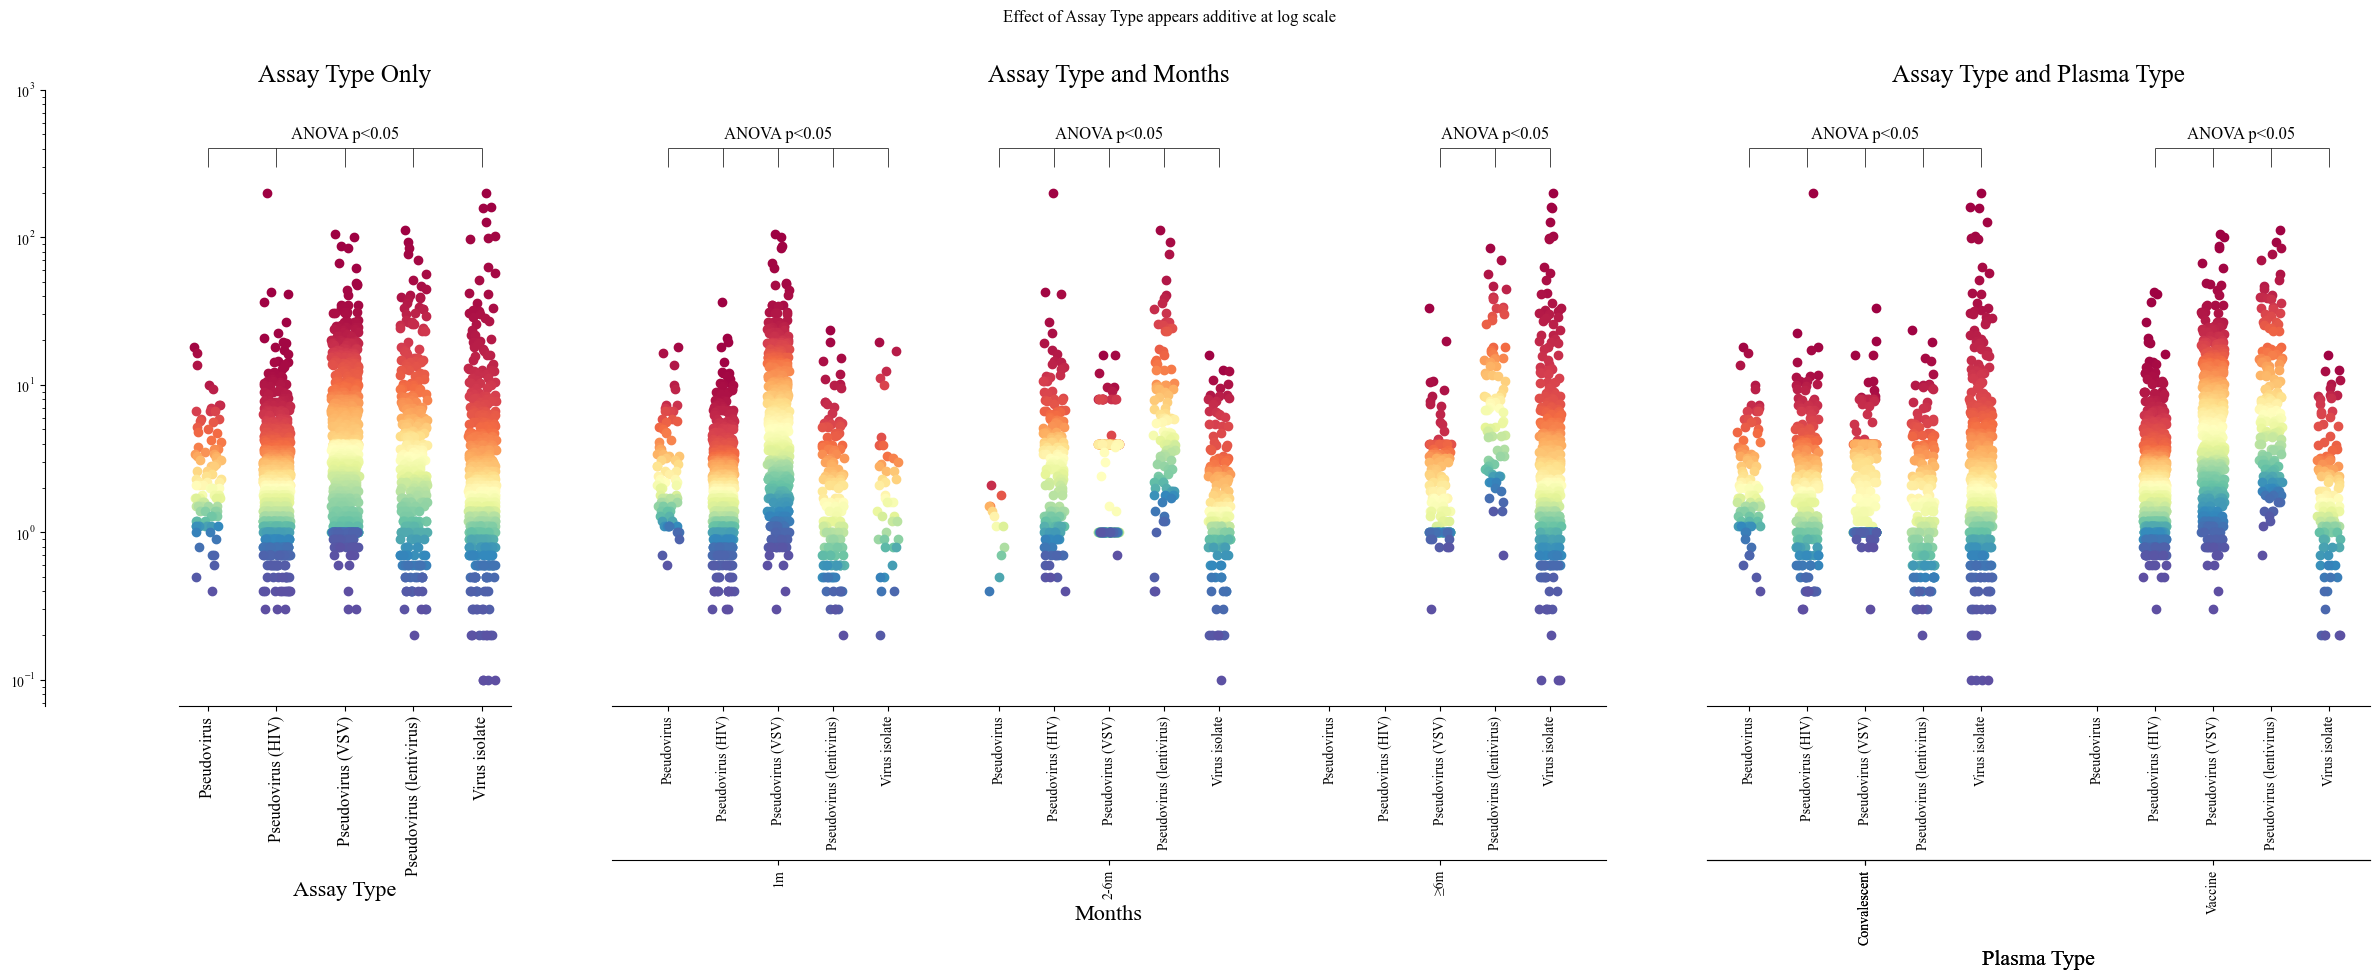

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(30, 8), gridspec_kw={'width_ratios': [0.1, 1, 3, 2]})

jitter_width = 0.4
palette='Spectral'

miny = plasma_lite['Fold Reduction: Median'].min()
maxy = plasma_lite['Fold Reduction: Median'].max()
n_assays = len(plasma_lite['Assay'].unique())

# First, just show Plasma types
ax = axes[1]
ax.set_title('Assay Type Only', fontsize=18)
ax.set_xlabel('Assay Type', fontsize=16)
s = []
xticklabels = []
for x, assay in enumerate(sorted(plasma_lite['Assay'].unique())):
    temp = plasma_lite[plasma_lite['Assay']==assay].copy()
    temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
    yvals = temp['Fold Reduction: Median']
    xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x
    color_map = sns.color_palette(palette, len(temp))
    colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
    for xi,yi,ci in zip (xvals, yvals, colors):
        ax.plot(xi, yi, 'o', color=ci)

    s.append(yvals)
    xticklabels.append(assay)
    
ax.set_xticks([i for i in range(len(xticklabels))])
ax.set_xticklabels(xticklabels, fontsize=12, rotation=90)

stat, p = f_oneway(*s)
if p<0.05:
    ax.vlines([i for i in range(len(xticklabels))], maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
    ax.hlines(maxy*2, 0, len(xticklabels)-1,
              color='black', linewidth=0.5)
    ax.text((len(xticklabels)-1)/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')
    


# Next, break up by Months
ax = axes[2]
ax.set_title('Assay Type and Months', fontsize=18)
# ax.set_xlabel('Months', fontsize=16)
xticklabels = []

for x, month in enumerate(sorted(plasma_lite['Months'].unique())):
    x *= n_assays+1
    s = []
    sx = []
    for j, assay in enumerate(sorted(plasma_lite['Assay'].unique())):
        temp = plasma_lite[(plasma_lite['Months']==month) & (plasma_lite['Assay']==assay)].copy()
        temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
        if len(temp) > 0:
            yvals = temp['Fold Reduction: Median']
            xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x + j
            color_map = sns.color_palette('Spectral', len(temp))
            colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
            for xi,yi,ci in zip (xvals, yvals, colors):
                ax.plot(xi, yi, 'o', color=ci)
                
            s.append(yvals)
            sx.append(x+j)
    if len(s)>1:
        stat, p = f_oneway(*s)
        if p<0.05:
            ax.vlines(sx, maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
            ax.hlines(maxy*2, min(sx), max(sx),
                      color='black', linewidth=0.5)
            ax.text((min(sx) + max(sx))/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')
    xticklabels.append(month)
        
# ax.set_xticks([i*(n_assays+1) + (n_assays-1)/2 for i in range(len(xticklabels))])
# ax.set_xticklabels(xticklabels)

ax.set_xticks([i*(n_assays+1)+offset for i in range(len(xticklabels)) for offset in range(n_assays)])
ax.set_xticklabels(sorted(plasma_lite['Assay'].unique())*len(xticklabels), rotation=90)

sec = ax.secondary_xaxis(location=-0.25)
sec.set_xticks([i*(n_assays+1) + (n_assays-1)/2 for i in range(len(xticklabels))])
sec.set_xticklabels(xticklabels, rotation=90)

sec.set_xlabel('Months', fontsize=16) 


# Next, break up by assay
ax = axes[3]
ax.set_title('Assay Type and Plasma Type', fontsize=18)
# ax.set_xlabel('Plasma', fontsize=16)
xticklabels = []

for x, plasma_type in enumerate(sorted(plasma_lite['Plasma'].unique())):
    x *= n_assays+1
    s = []
    sx = []
    for j, assay in enumerate(sorted(plasma_lite['Assay'].unique())):
        temp = plasma_lite[(plasma_lite['Assay']==assay) & (plasma_lite['Plasma']==plasma_type)].copy()
        temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
        if len(temp) > 0:
            yvals = temp['Fold Reduction: Median']
            xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x + j
            color_map = sns.color_palette('Spectral', len(temp))
            colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
            for xi,yi,ci in zip (xvals, yvals, colors):
                ax.plot(xi, yi, 'o', color=ci)
                
            s.append(yvals)
            sx.append(x+j)
    if len(s)>1:
        stat, p = f_oneway(*s)
        if p<0.05:
            ax.vlines(sx, maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
            ax.hlines(maxy*2, min(sx), max(sx),
                      color='black', linewidth=0.5)
            ax.text((min(sx) + max(sx))/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')
            
    xticklabels.append(plasma_type)
        
    # ax.set_xticks([i*(n_assays+1) + (n_assays-1)/2 for i in range(len(xticklabels))])
    # ax.set_xticklabels(xticklabels)  

    ax.set_xticks([i*(n_assays+1)+offset for i in range(len(xticklabels)) for offset in range(n_assays)])
    ax.set_xticklabels(sorted(plasma_lite['Assay'].unique())*len(xticklabels), rotation=90)

    sec = ax.secondary_xaxis(location=-0.25)
    sec.set_xticks([i*(n_assays+1) + (n_assays-1)/2 for i in range(len(xticklabels))])
    sec.set_xticklabels(xticklabels, rotation=90)

    sec.set_xlabel('Plasma Type', fontsize=16) 
    
# Format leftmost (reference) axis:
ax = axes[0]
ax.set_yscale('log')
ax.set_ylim([miny/1.5,
             maxy*5])
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.set_xticks([], minor=True)
ax.set_xticks([], minor=False)
# Format plotted axes
for ax in axes[1:]:
    ax.set_yscale('log')
    ax.set_ylim([miny/1.5,
                 maxy*5])
    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.set_yticks([], minor=True)
    ax.set_yticks([], minor=False)
    
    
fig.suptitle('Effect of Assay Type appears additive at log scale');

fig.savefig('figs/covdb/assay_type_effect.png', dpi=150);

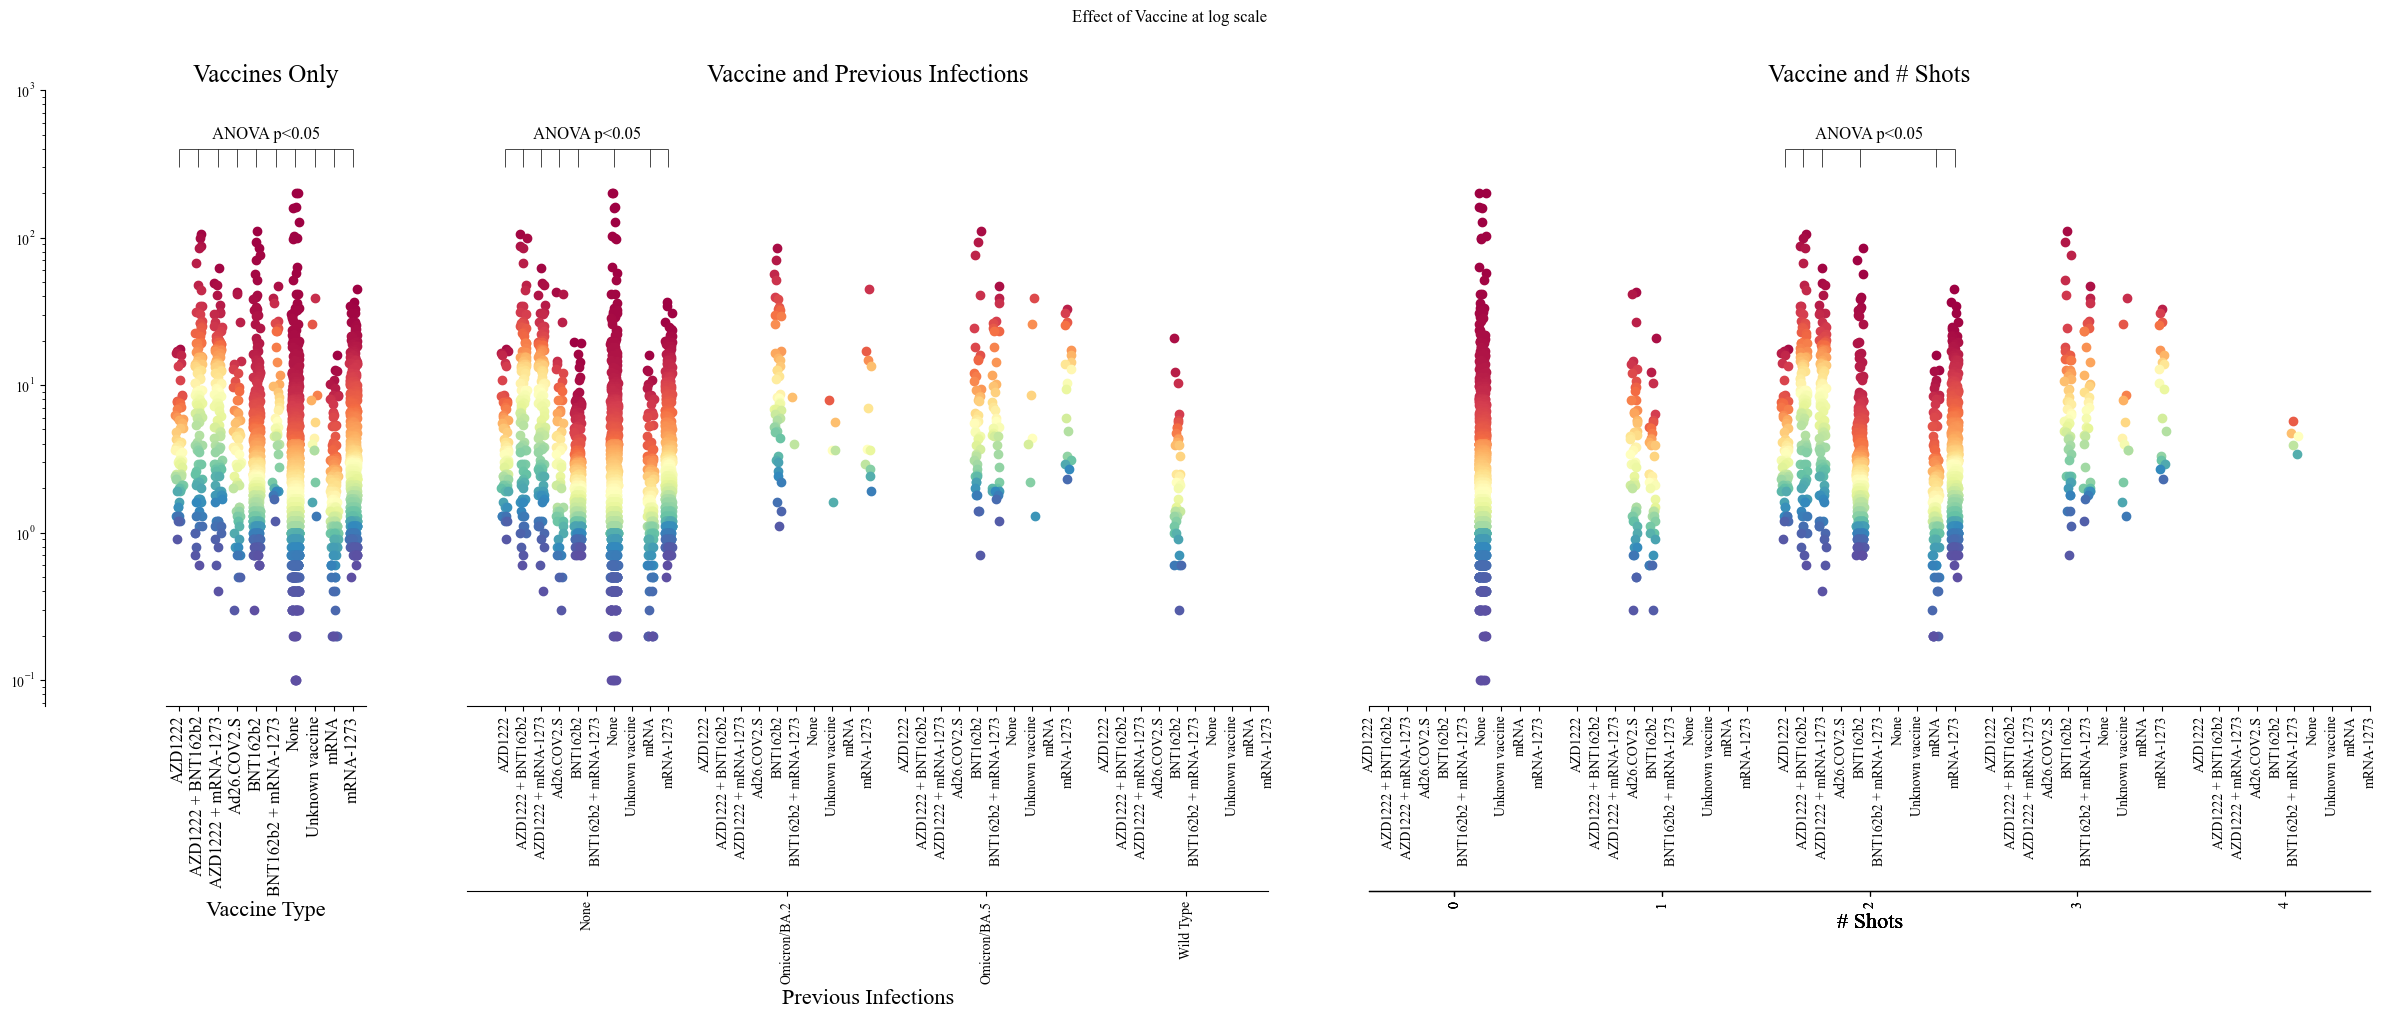

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(30, 8), gridspec_kw={'width_ratios': [0.1, 1, 4, 5]})

jitter_width = 0.4
palette='Spectral'

miny = plasma_lite['Fold Reduction: Median'].min()
maxy = plasma_lite['Fold Reduction: Median'].max()
n_vaccines = len(plasma_lite['Vaccine'].unique())

# First, show Months
ax = axes[1]
ax.set_title('Vaccines Only', fontsize=18)
ax.set_xlabel('Vaccine Type', fontsize=16)
s = []
xticklabels = []
for x, vax in enumerate(sorted(plasma_lite['Vaccine'].unique())):
    temp = plasma_lite[plasma_lite['Vaccine']==vax].copy()
    temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
    yvals = temp['Fold Reduction: Median']
    xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x
    color_map = sns.color_palette(palette, len(temp))
    colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
    for xi,yi,ci in zip (xvals, yvals, colors):
        ax.plot(xi, yi, 'o', color=ci)

    s.append(yvals)
    xticklabels.append(vax)
    
ax.set_xticks([i for i in range(len(xticklabels))])
ax.set_xticklabels(xticklabels, fontsize=12, rotation=90)

stat, p = f_oneway(*s)
if p<0.05:
    ax.vlines([i for i in range(len(xticklabels))], maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
    ax.hlines(maxy*2, 0, len(xticklabels)-1,
              color='black', linewidth=0.5)
    ax.text((len(xticklabels)-1)/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')
    


# Next, break up by Pre-Vax Infection
ax = axes[2]
ax.set_title('Vaccine and Previous Infections', fontsize=18)
# ax.set_xlabel('Previous Infections', fontsize=16)
xticklabels = []

for x, prev in enumerate(sorted(plasma_lite['Pre-vaccine Infection'].unique())):
    x *= n_vaccines+1
    s = []
    sx = []
    for j, vax in enumerate(sorted(plasma_lite['Vaccine'].unique())):
        temp = plasma_lite[(plasma_lite['Pre-vaccine Infection']==prev) & (plasma_lite['Vaccine']==vax)].copy()
        temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
        if len(temp) > 0:
            yvals = temp['Fold Reduction: Median']
            xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x + j
            color_map = sns.color_palette('Spectral', len(temp))
            colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
            for xi,yi,ci in zip (xvals, yvals, colors):
                ax.plot(xi, yi, 'o', color=ci)
                
            s.append(yvals)
            sx.append(x+j)
    if len(s)>1:
        stat, p = f_oneway(*s)
        if p<0.05:
            ax.vlines(sx, maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
            ax.hlines(maxy*2, min(sx), max(sx),
                      color='black', linewidth=0.5)
            ax.text((min(sx) + max(sx))/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')
    xticklabels.append(prev)
        
# ax.set_xticks([i*(n_vaccines+1) + (n_vaccines-1)/2 for i in range(len(xticklabels))])
# ax.set_xticklabels(xticklabels)

ax.set_xticks([i*(n_vaccines+1)+offset for i in range(len(xticklabels)) for offset in range(n_vaccines)])
ax.set_xticklabels(sorted(plasma_lite['Vaccine'].unique())*len(xticklabels), rotation=90)

sec = ax.secondary_xaxis(location=-0.3)
sec.set_xticks([i*(n_vaccines+1) + (n_vaccines-1)/2 for i in range(len(xticklabels))])
sec.set_xticklabels(xticklabels, rotation=90)

sec.set_xlabel('Previous Infections', fontsize=16) 


# Next, break up by shots
ax = axes[3]
ax.set_title('Vaccine and # Shots', fontsize=18)
# ax.set_xlabel('# Shots', fontsize=16)
xticklabels = []

for x, shot in enumerate(sorted(plasma_lite['# Shots'].unique())):
    x *= n_vaccines+1
    s = []
    sx = []
    for j, vax in enumerate(sorted(plasma_lite['Vaccine'].unique())):
        temp = plasma_lite[(plasma_lite['Vaccine']==vax) & (plasma_lite['# Shots']==shot)].copy()
        temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
        if len(temp) > 0:
            yvals = temp['Fold Reduction: Median']
            xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x + j
            color_map = sns.color_palette('Spectral', len(temp))
            colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
            for xi,yi,ci in zip (xvals, yvals, colors):
                ax.plot(xi, yi, 'o', color=ci)
                
            s.append(yvals)
            sx.append(x+j)
    if len(s)>1:
        stat, p = f_oneway(*s)
        if p<0.05:
            ax.vlines(sx, maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
            ax.hlines(maxy*2, min(sx), max(sx),
                      color='black', linewidth=0.5)
            ax.text((min(sx) + max(sx))/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')
            
    xticklabels.append(shot)
        
    # ax.set_xticks([i*(n_vaccines+1) + (n_vaccines-1)/2 for i in range(len(xticklabels))])
    # ax.set_xticklabels(xticklabels) 
    
    ax.set_xticks([i*(n_vaccines+1)+offset for i in range(len(xticklabels)) for offset in range(n_vaccines)])
    ax.set_xticklabels(sorted(plasma_lite['Vaccine'].unique())*len(xticklabels), rotation=90)

    sec = ax.secondary_xaxis(location=-0.3)
    sec.set_xticks([i*(n_vaccines+1) + (n_vaccines-1)/2 for i in range(len(xticklabels))])
    sec.set_xticklabels(xticklabels, rotation=90)

    sec.set_xlabel('# Shots', fontsize=16) 

# Format leftmost (reference) axis:
ax = axes[0]
ax.set_yscale('log')
ax.set_ylim([miny/1.5,
             maxy*5])
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.set_xticks([], minor=True)
ax.set_xticks([], minor=False)
# Format plotted axes
for ax in axes[1:]:
    ax.set_yscale('log')
    ax.set_ylim([miny/1.5,
                 maxy*5])
    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.set_yticks([], minor=True)
    ax.set_yticks([], minor=False)
    
    
fig.suptitle('Effect of Vaccine at log scale');

fig.savefig('figs/covdb/vaccine_effect.png', dpi=150);

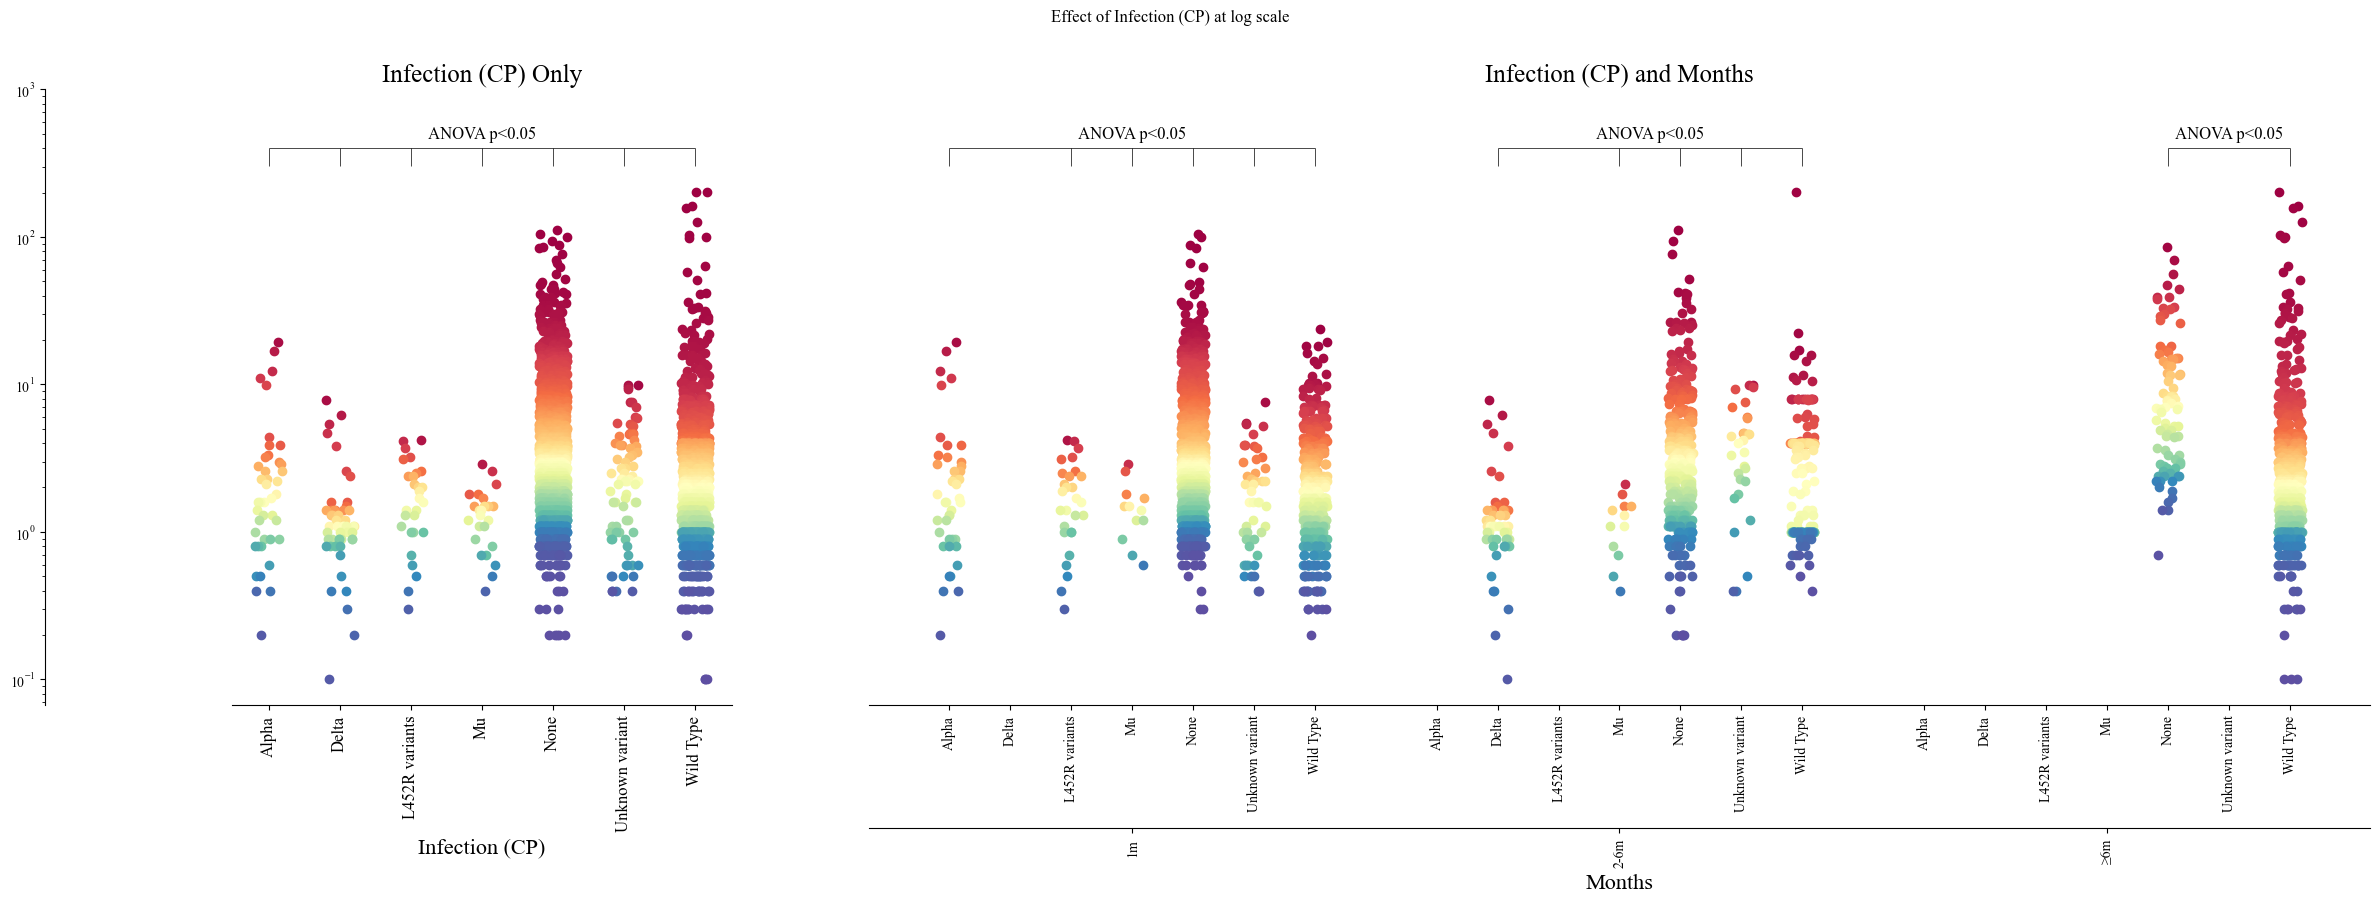

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8), gridspec_kw={'width_ratios': [0.1, 1, 3]})

jitter_width = 0.4
palette='Spectral'

miny = plasma_lite['Fold Reduction: Median'].min()
maxy = plasma_lite['Fold Reduction: Median'].max()
n_infections = len(plasma_lite['Infection (CP)'].unique())

# First, show Months
ax = axes[1]
ax.set_title('Infection (CP) Only', fontsize=18)
ax.set_xlabel('Infection (CP)', fontsize=16)
s = []
xticklabels = []
for x, inf in enumerate(sorted(plasma_lite['Infection (CP)'].unique())):
    temp = plasma_lite[plasma_lite['Infection (CP)']==inf].copy()
    temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
    yvals = temp['Fold Reduction: Median']
    xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x
    color_map = sns.color_palette(palette, len(temp))
    colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
    for xi,yi,ci in zip (xvals, yvals, colors):
        ax.plot(xi, yi, 'o', color=ci)

    s.append(yvals)
    xticklabels.append(inf)
    
ax.set_xticks([i for i in range(len(xticklabels))])
ax.set_xticklabels(xticklabels, fontsize=12, rotation=90)

stat, p = f_oneway(*s)
if p<0.05:
    ax.vlines([i for i in range(len(xticklabels))], maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
    ax.hlines(maxy*2, 0, len(xticklabels)-1,
              color='black', linewidth=0.5)
    ax.text((len(xticklabels)-1)/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')
    


# Next, break up by Months
ax = axes[2]
ax.set_title('Infection (CP) and Months', fontsize=18)
# ax.set_xlabel('Months', fontsize=16)
xticklabels = []

for x, month in enumerate(sorted(plasma_lite['Months'].unique())):
    x *= n_infections+1
    s = []
    sx = []
    for j, inf in enumerate(sorted(plasma_lite['Infection (CP)'].unique())):
        temp = plasma_lite[(plasma_lite['Months']==month) & (plasma_lite['Infection (CP)']==inf)].copy()
        temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
        if len(temp) > 0:
            yvals = temp['Fold Reduction: Median']
            xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x + j
            color_map = sns.color_palette('Spectral', len(temp))
            colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
            for xi,yi,ci in zip (xvals, yvals, colors):
                ax.plot(xi, yi, 'o', color=ci)
                
            s.append(yvals)
            sx.append(x+j)
    if len(s)>1:
        stat, p = f_oneway(*s)
        if p<0.05:
            ax.vlines(sx, maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
            ax.hlines(maxy*2, min(sx), max(sx),
                      color='black', linewidth=0.5)
            ax.text((min(sx) + max(sx))/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')
    xticklabels.append(month)
        
# ax.set_xticks([i*(n_infections+1) + (n_infections-1)/2 for i in range(len(xticklabels))])
# ax.set_xticklabels(xticklabels)
ax.set_xticks([i*(n_infections+1)+offset for i in range(len(xticklabels)) for offset in range(n_infections)])
ax.set_xticklabels(sorted(plasma_lite['Infection (CP)'].unique())*len(xticklabels), rotation=90)

sec = ax.secondary_xaxis(location=-0.2)
sec.set_xticks([i*(n_infections+1) + (n_infections-1)/2 for i in range(len(xticklabels))])
sec.set_xticklabels(xticklabels, rotation=90)

sec.set_xlabel('Months', fontsize=16) 


# Format leftmost (reference) axis:
ax = axes[0]
ax.set_yscale('log')
ax.set_ylim([miny/1.5,
             maxy*5])
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.set_xticks([], minor=True)
ax.set_xticks([], minor=False)
# Format plotted axes
for ax in axes[1:]:
    ax.set_yscale('log')
    ax.set_ylim([miny/1.5,
                 maxy*5])
    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.set_yticks([], minor=True)
    ax.set_yticks([], minor=False)
    
    
fig.suptitle('Effect of Infection (CP) at log scale');

fig.savefig('figs/covdb/infection_cp_effect.png', dpi=150);

---
## Model

In [10]:
def one_hot(mutations: pd.Series):
    features = sorted(list(set(' + '.join(filter(None, mutations.tolist())).split(' + '))))
    onehot = [[1 if mut.strip() in str(muts) else 0 for mut in features] for muts in mutations]
    
    return torch.tensor(onehot, dtype=d), features

In [11]:
def model(X, Y, plasma_type_data, assay_type_data, vaccines):
    
    # Sample plasma type effects
    μ_P = torch.tensor(0.)
    σ_P = torch.tensor(1.)
    with pyro.plate('plasmas_plate', len(set(plasma_type_data))):
        P = pyro.sample('P', dist.Normal(μ_P, σ_P))
        
    # Sample assay type effects
    μ_A = 0.
    σ_A = 1.
    with pyro.plate('assays_plate', len(set(assay_type_data))):
        A = pyro.sample('A', dist.Normal(μ_A, σ_A))
        
    # Sample vaccine effects
    μ_ω = 0.
    σ_ω = .1
    with pyro.plate('ω_plate', len(set(vaccines))):
        ω = pyro.sample('ω', dist.Normal(μ_ω, σ_ω))
        
    # Sample mutation specific effects
    μ_β = 0.
    σ_β = .1
    with pyro.plate('β_plate', X.shape[1]):
        β = pyro.sample('β', dist.Normal(μ_β, σ_β))
        
    # Make predictions
    prediction = torch.matmul(X, β) + A[torch.tensor(assay_type_data)] + P[torch.tensor(plasma_type_data)]
    # prediction = A[torch.tensor(assay_type_data)] + P[torch.tensor(plasma_type_data)]
    
    # Score observation
    σ = pyro.param("σ", dist.LogNormal(0, .01))
    # σ = pyro.sample("σ", dist.HalfNormal(.01, .01))
    with pyro.plate("data", X.shape[0]):
        return pyro.sample("obs", dist.Normal(prediction, σ), obs=Y)
    
def guide(X, Y, plasma_type_data, assay_type_data, vaccines):
    μ_P = pyro.param('μ_P_q', torch.zeros(len(set(plasma_type_data))))
    σ_P = pyro.param('σ_P_q', 0.1*torch.ones(len(set(plasma_type_data))), constraint=constraints.positive)
    with pyro.plate('plasmas_plate', len(set(plasma_type_data))):
        P = pyro.sample('P', dist.Normal(μ_P, σ_P))
        
    μ_A = pyro.param('μ_A_q', torch.zeros(len(set(assay_type_data))))
    σ_A = pyro.param('σ_A_q', 0.1*torch.ones(len(set(assay_type_data))), constraint=constraints.positive)
    with pyro.plate('assays_plate', len(set(assay_type_data))):
        A = pyro.sample('A', dist.Normal(μ_A, σ_A))
        
    μ_β = pyro.param('μ_β_q', torch.zeros(X.shape[1]))
    σ_β = pyro.param('σ_β_q', 0.1*torch.ones(X.shape[1]), constraint=constraints.positive)
    with pyro.plate('β_plate', X.shape[1]):
        β = pyro.sample('β', dist.Normal(μ_β, σ_β))
        
    σ = pyro.param('σ', 0.1*torch.ones(1), constraint=constraints.positive)
    # σ = pyro.sample('σ', dist.HalfNormal(.01, .01))

In [12]:
X, features = one_hot(plasma_lite['Variant: Mutations'])
Y = torch.tensor(plasma_lite['Log fold reduction'].values, dtype=d)
assert X.shape[0], X.shape[1] == [len(plasma_lite), len(features)]
assert Y.shape[0] == len(plasma_lite)

plasma_type_encoder = LabelEncoder()
assay_type_encoder = LabelEncoder()
vaccine_encoder = LabelEncoder()

plasma_type_data = plasma_type_encoder.fit_transform(plasma_lite['Plasma'])
assay_type_data = assay_type_encoder.fit_transform(plasma_lite['Assay'])
vaccines = vaccine_encoder.fit_transform(plasma_lite['Vaccine'])


svi_data = dict()
svi_data['X'] = X
svi_data['Y'] = Y
svi_data['features'] = features
svi_data['plasma_type_data'] = plasma_type_data
svi_data['plasma_type_map'] = plasma_type_encoder.inverse_transform([i for i in range(len(set(plasma_type_data)))])
svi_data['assay_type_data'] = assay_type_data
svi_data['assay_type_map'] = assay_type_encoder.inverse_transform([i for i in range(len(set(assay_type_data)))])
svi_data['vaccines'] = vaccines
svi_data['vaccines_map'] = vaccine_encoder.inverse_transform([i for i in range(len(set(vaccines)))])

---
## Run SVI

In [13]:
def save_results(params, traces, svi_data, date):
    results = dict()
    results['params'] = dict(params)
    results['traces'] = traces
    results['data'] = svi_data
    
    outfile = f'model_covdb/results.{date}.pt'
    torch.save(results, outfile)
    return results
    
def load_results(load_date):
    results = torch.load(f'model_covdb/results.{load_date}.pt')
    return results

In [14]:
if run_SVI:
    pyro.clear_param_store()
    
    adam_params = {"lr": 0.05, "betas": (0.90, 0.999)}
    optimizer = Adam(adam_params)
    
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
    
    traces = defaultdict(list)
    
    n_steps = 50001
    trace_len = 500
    for step in trange(n_steps):
        svi.step(X, Y, plasma_type_data, assay_type_data, vaccines)
        if step % (n_steps//trace_len) == 0:
            params = pyro.get_param_store()
            for key in params.keys():
                traces[key].append(params[key].clone().detach())
                traces['ELBO'].append(torch.tensor(svi.evaluate_loss(X, Y, plasma_type_data, assay_type_data, vaccines)))
    
    results = save_results(params, traces, svi_data, date)

else:
    results = load_results(date)

#### Inspect traces for convergence

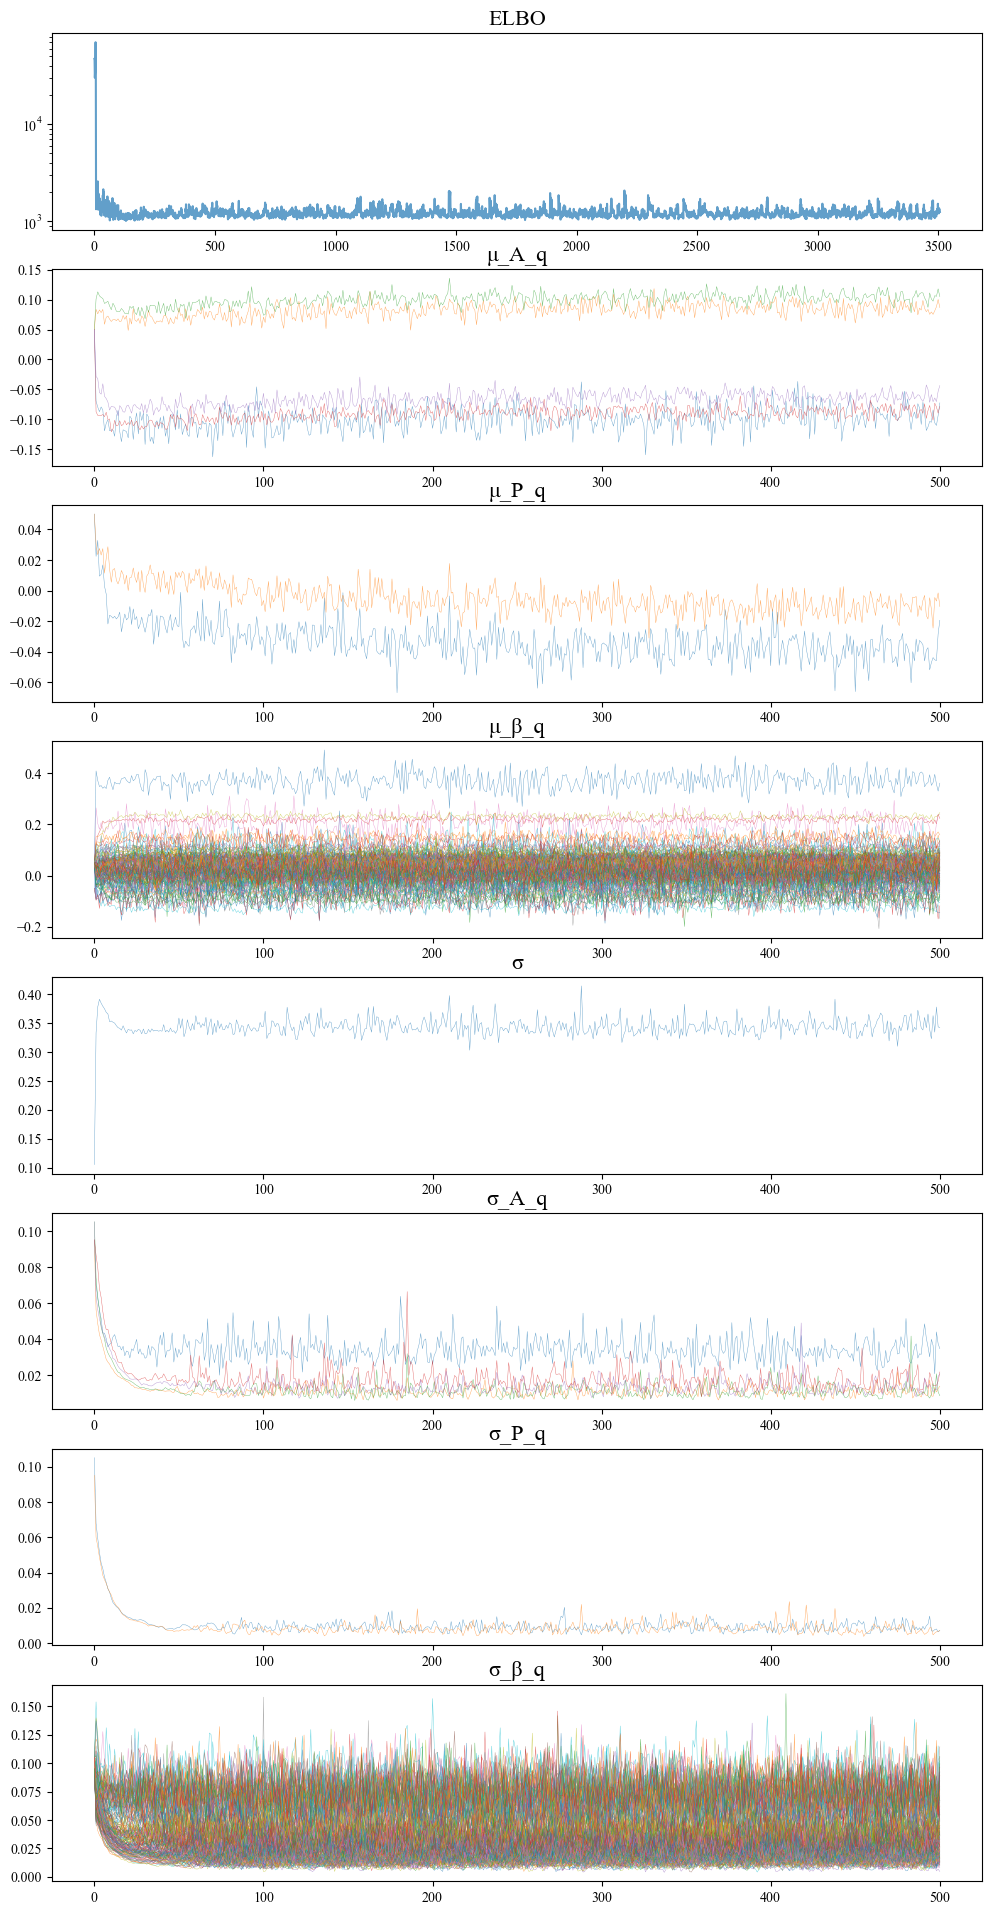

In [15]:
traces = results['traces']
n_latents = len(traces.keys())
fig, axes = plt.subplots(n_latents, 1, figsize=(12, 3*n_latents))

for ax, latent in zip(axes, sorted(traces.keys())):
    trace = torch.stack(traces[latent])
    if len(trace.shape) == 1:
        ax.plot(trace, alpha=0.7)
        if latent == 'ELBO':
            ax.set_yscale('log');
    else:
        for subsample in range(trace.shape[-1]):
            ax.plot(trace[:, subsample], alpha=0.7, linewidth=0.3)
            
    ax.set_title(latent, fontsize=16)
    
fig.savefig(f'figs/covdb/svi_traces_{date}.png')

---
## Evaluate Model Fit

In [16]:
def pred_y(X, plasma_type_data, assay_type_data, vaccines, β, P, A):
    prediction = torch.matmul(X, β) + A[torch.tensor(assay_type_data)] + P[torch.tensor(plasma_type_data)]
    return prediction

Y_pred = pred_y(X, 
                plasma_type_data, 
                assay_type_data, 
                vaccines, 
                results['params']['μ_β_q'], 
                results['params']['μ_P_q'], 
                results['params']['μ_A_q'])

In [17]:
sse = sum((Y_pred - Y)**2)
avg_err = sum((Y_pred - Y)**2).sqrt() / len(Y)
print('SSE: {:.2f}'.format(sse))
print('Avg abs Error Per Obs: {:.4f}'.format(avg_err))

SSE: 336.16
Avg abs Error Per Obs: 0.0063


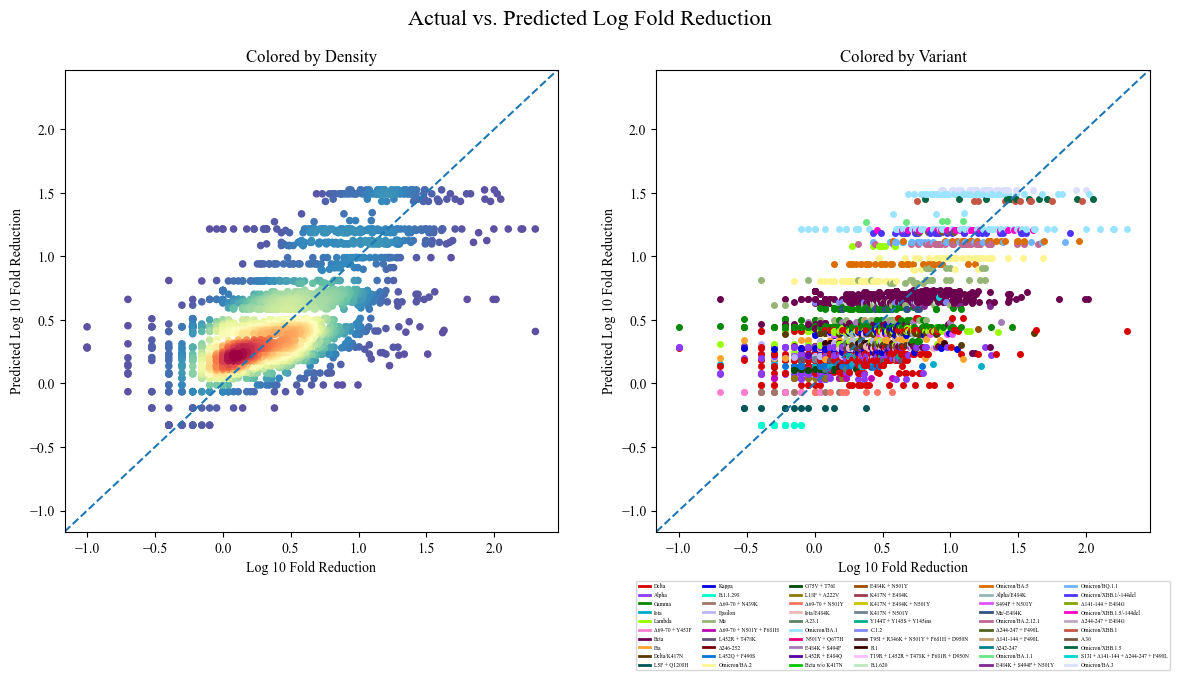

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# First plot, color by variant
ax = axes[1]
ax.set_title('Colored by Variant')
varns = plasma['Variant'].unique().tolist()
palette = cc.glasbey[:len(varns)]  #sns.color_palette('tab10', len(varns))
for i, row in plasma.iterrows():
    ax.plot(Y[i], Y_pred[i], marker='o', markersize=4, color=palette[varns.index(row['Variant'])])
    
legend_elements = [Line2D([0], [0], color=color, lw=2, label=label) for color, label in zip(palette, varns)]
ax.legend(handles=legend_elements, labels=varns, fontsize=4, ncols=len(varns)/10, bbox_to_anchor=[0.5, -0.1], loc='upper center')
    
# Second plot, color by density
ax = axes[0]
ax.set_title('Colored by Density')
xy = torch.stack([Y,Y_pred])
z = gaussian_kde(xy)(xy)
idx = z.argsort()
x, y, z = Y[idx], Y_pred[idx], z[idx]
ax.scatter(x, y, c=z, s=20, cmap='Spectral_r')
    
for ax in axes:
    ymin = min(Y.min(), Y_pred.min())
    ymax = max(Y.max(), Y_pred.max())
    yrange = ymax - ymin
    ymin -= 0.05*yrange
    ymax += 0.05*yrange
    line = np.linspace(ymin, ymax)
    ax.plot(line, line, linestyle='--')

    ax.set_xlim(ymin, ymax);
    ax.set_ylim(ymin, ymax);
    
    ax.set_xlabel('Log 10 Fold Reduction')
    ax.set_ylabel('Predicted Log 10 Fold Reduction')
    
fig.suptitle('Actual vs. Predicted Log Fold Reduction', fontsize=16);
# fig.savefig(f'figs/covdb/actual_vs_predicted_{date}.png')

Notice in the figure colored by variant: there are many horizontal color bands, indicating that there are many isolates of the same variant with the same _predicted_ fold reduction, but wide ranges of _observed_ fold reduction. An example is shown below, illustrating that no clear variable comes forward to explain the wide range in neutralization values.

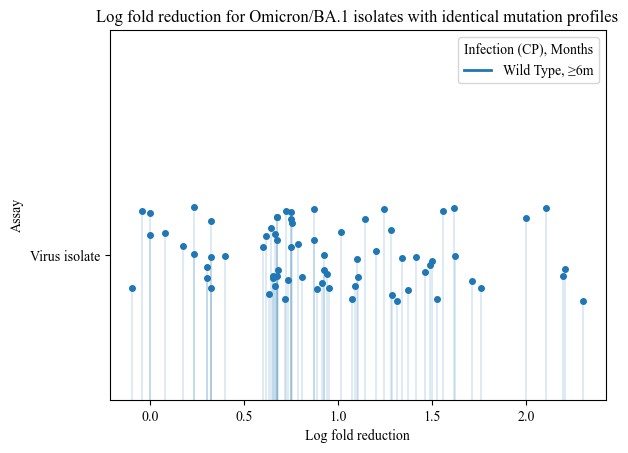

In [19]:
idxs = (np.abs(Y_pred - Y_pred[-2]) < 0.01).nonzero().squeeze().tolist()
temp = plasma.iloc[idxs][['Reference', 'Assay', 'Pre-vaccine Infection', 'Vaccine', '# Shots',
       'Months', 'Variant', 'Variant: Pos', 'Variant: Mutations',
       'Potency: NT50 Cmp', 'Potency: NT50 GeoMean', 'Potency: NT50 GSD',
       'Fold Reduction: Cmp', 'Fold Reduction: Median', 'Plasma',
       'Infection (CP)', 'Log fold reduction']]
temp['Infection (CP), Months'] = temp['Infection (CP)'] + ', ' + temp['Months']

fig, ax = plt.subplots()

y = 'Assay'
hue = 'Infection (CP), Months'
jitterwidth=0.3
palette = sns.color_palette('tab10')
for ypos, yval in enumerate(temp[y].unique()):
    data = temp[temp[y]==yval]
    for i, c in enumerate(temp[hue].unique()):
        data = data[data[hue]==c]
        yvals = [1.5*jitterwidth+ypos]*len(data)+(np.random.rand(len(data))-0.5)*jitterwidth
        ax.plot(data['Log fold reduction'], yvals, marker='o', markersize=4, color=palette[i], linestyle='')
        ax.vlines(data['Log fold reduction'], 0, yvals, linewidth=0.2)
                
legend_elements = [Line2D([0], [0], color=color, lw=2, label=label) for color, label in zip(palette, temp[hue].unique())]
ax.legend(handles=legend_elements, labels=temp[hue].unique(), loc='upper right', title=hue)

ax.set_yticks([1.5*jitterwidth+i for i in range(len(temp[y].unique()))]);
ax.set_yticklabels(temp[y].unique());

ax.set_ylim([0, len(temp[y].unique())+.5*jitterwidth]);

ax.set_ylabel(y);
ax.set_xlabel('Log fold reduction');

ax.set_title('Log fold reduction for Omicron/BA.1 isolates with identical mutation profiles');

residuals std: 0.33337071537971497


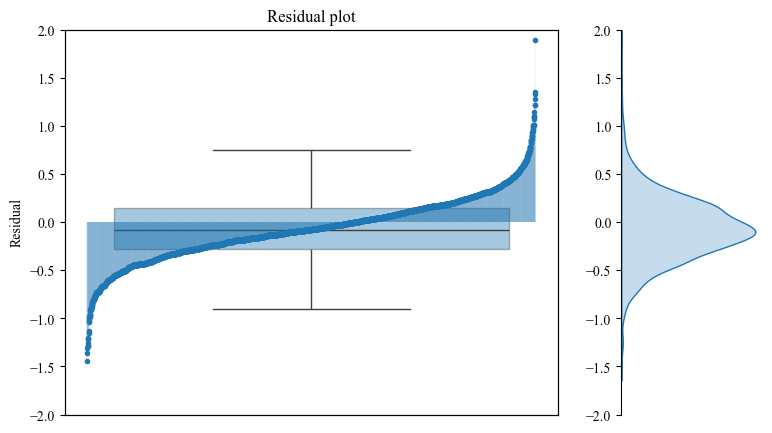

In [27]:
# Dist of residuals 
residuals = Y - Y_pred

fig, axes = plt.subplots(1, 2, figsize=(9, 5), gridspec_kw={'width_ratios':[7,2]})
ax = axes[0]
# First, plot points
sns.boxplot(x=0.5,
            y=residuals,
            showfliers=False,
            boxprops={"alpha": 0.4, "facecolor":'tab:blue'},
            ax=ax)
ax.set_xticks([])
ax.set_ylabel('Residual')
ax = ax.twiny()
ax.plot([i/len(residuals) for i in range(len(residuals))], sorted(residuals), 
        marker='o', color='tab:blue', markersize=3,
        linestyle='')
ax.vlines([i/len(residuals) for i in range(len(residuals))], 0, sorted(residuals), linestyle='-', linewidth=0.2, color='tab:blue', alpha=0.4)
ax.set_xticks([])
ax.set_title('Residual plot')
ax.set_ylim([-2,2])

ax = axes[1]
sns.kdeplot(y=residuals,
            fill=True,
            ax=ax)
ax.spines[['right', 'top', 'bottom']].set_visible(False)
ax.set_xticks([])
# ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('');
ax.set_ylim(axes[0].get_ylim());

print(f'residuals std: {residuals.std().item()}')

---
## Save CSV of Results

In [21]:
results_df = pd.DataFrame({'Mutation':results['data']['features'],
                           'μ_β_q':results['params']['μ_β_q'].tolist(),
                           'σ_β_q':results['params']['σ_β_q'].tolist(),
                           'N':results['data']['X'].sum(axis=0).int()})
outdir = f'results/covdb/{date}/'
if not os.path.exists(outdir):
    os.mkdir(outdir)
results_df.to_csv(outdir+'mutation_effects.csv', index=False)

assay_biases = dict(zip(svi_data['assay_type_map'], results['params']['μ_A_q'].tolist()))
plasma_biases = dict(zip(svi_data['plasma_type_map'], results['params']['μ_P_q'].tolist()))
with open(outdir+'plasma_biases.json', 'w') as handle:
    json.dump(plasma_biases, handle)
with open(outdir+'assay_biases.json', 'w') as handle:
    json.dump(assay_biases, handle)

---
## Explore model results

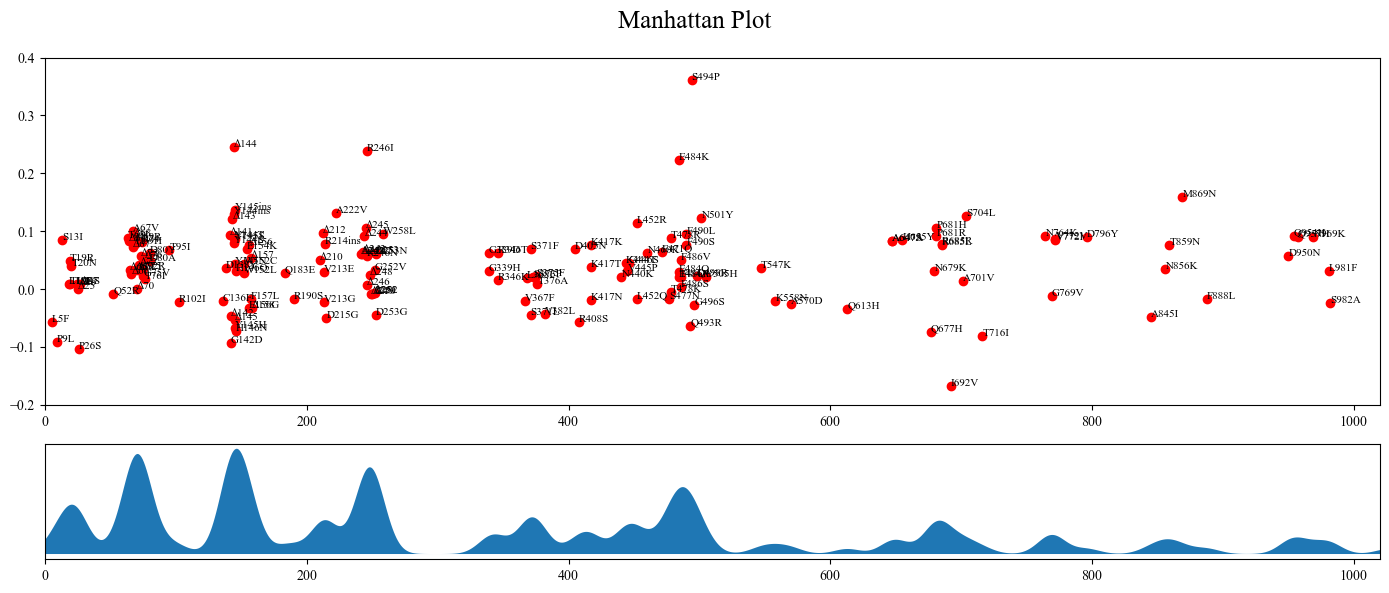

In [22]:
# Manhattan plot
def setup():
    fig, axes = plt.subplots(2,1, figsize=(14,6), gridspec_kw={'height_ratios': [4.5, 1.5]})
    
    options= dict()
    options['xlim'] = [0, 1020]
    options['ylim'] = [-0.2, 0.4] #[-1, 1]
    
    axes[0].set_xlim(options['xlim'])
    axes[0].set_ylim(options['ylim'])
    
    axes[1].set_xlim(options['xlim'])
    axes[1].set_yticks([])
    
    return fig, axes, options

def get_positions(mutations):
    coefficients = mutations.copy()
    
    positions = [int(''.join(filter(str.isdigit, c))) for c in coefficients] #[int(c[1:-1]) for c in coefficients]
    return positions, coefficients

def plot_coef(ax, effects, positions, mutations, options):
    ax.plot(positions, effects, 'ro')
    
    texts = []
    for i, (pos, fea) in enumerate(zip(positions, mutations)):
        x = pos
        y = effects[i]
        text = fea #+ '\n' + '{:1.2f}'.format(y)
        texts.append(ax.annotate(text, xy=(x, y), xytext=(x, y), fontsize=8))

    # adjust_text(texts);
    
    ax.set_xlim(options['xlim'])
    
def plot_density(ax, positions, options):
    xlim = options['xlim']
    ylim = options['ylim']
    num_points=1000
    # Fit KDE
    kde = KDE(kernel='gaussian', bandwidth=10).fit(np.array(positions).reshape(-1,1))
    x = np.linspace(xlim[0], xlim[1], num_points).reshape(-1,1)
    # Generate KDE curve
    y = np.exp(kde.score_samples(x))
    
    ax.fill_between(x.flatten(), np.zeros_like(y), y)
    
    return kde


fig, axes, options = setup()
positions, mutations = get_positions(features)
kde = plot_density(axes[1], positions, options)
plot_coef(axes[0], results['params']['μ_β_q'], positions, mutations, options)
fig.suptitle('Manhattan Plot', fontsize=18)
fig.tight_layout()
fig.savefig(f'figs/covdb/Manhattan_{date}.png', dpi=150)

In [23]:
plasma

,Reference,Reference: DOI,Assay,Section,Pre-vaccine Infection,Vaccine,# Shots,Months,Host,Control,...,Variant: Mutations,# Results,Potency: NT50 Cmp,Potency: NT50 GeoMean,Potency: NT50 GSD,Fold Reduction: Cmp,Fold Reduction: Median,Plasma,Infection (CP),Log fold reduction
0,Turelli22,10.1101/2022.05.02.22274436,Virus isolate,Figure 2G,None,None,0,2-6m,Human,Wild Type (B.1),...,T19R + G142D + Δ156 + Δ157 + L452R + T478K + P...,1,=,1930.0,1.0,=,0.1,Convalescent,Delta,-1.000000
1,Wratil22,10.1038/s41591-022-01715-4,Virus isolate,Source Data Figure 1,None,None,0,≥6m,Human,Wild Type (B.1),...,Δ69 + G72R + Δ144 + N501Y + A570D + P681H + T7...,1,=,897.0,1.0,=,0.1,Convalescent,Wild Type,-1.000000
2,Wratil22,10.1038/s41591-022-01715-4,Virus isolate,Source Data Figure 1,None,None,0,≥6m,Human,Wild Type (B.1),...,L18F + T20N + P26S + D138Y + R190S + K417T + E...,1,=,1538.0,1.0,=,0.1,Convalescent,Wild Type,-1.000000
3,Wratil22,10.1038/s41591-022-01715-4,Virus isolate,Source Data Figure 1,None,None,0,≥6m,Human,Wild Type (B.1),...,Δ69 + G72R + Δ144 + N501Y + A570D + P681H + T7...,1,=,1005.0,1.0,=,0.1,Convalescent,Wild Type,-1.000000
4,Turelli22,10.1101/2022.05.02.22274436,Virus isolate,Figure 2I,None,mRNA,2,2-6m,Human,Wild Type (B.1),...,L5F + T95I + D253G + E484K + A701V,1,=,544.0,1.0,=,0.2,Vaccine,None,-0.698970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2897,Wratil22,10.1038/s41591-022-01715-4,Virus isolate,Source Data Figure 1,None,None,0,≥6m,Human,Wild Type (B.1),...,A67V + Δ69 + Δ70 + G142D + Δ143 + Δ144 + Δ145 ...,1,=,142.0,1.0,=,126.6,Convalescent,Wild Type,2.102434
2898,Wratil22,10.1038/s41591-022-01715-4,Virus isolate,Source Data Figure 1,None,None,0,≥6m,Human,Wild Type (B.1),...,A67V + Δ69 + Δ70 + G142D + Δ143 + Δ144 + Δ145 ...,1,=,16.0,1.0,=,157.6,Convalescent,Wild Type,2.197556
2899,Wratil22,10.1038/s41591-022-01715-4,Virus isolate,Source Data Figure 1,None,None,0,≥6m,Human,Wild Type (B.1),...,A67V + Δ69 + Δ70 + G142D + Δ143 + Δ144 + Δ145 ...,1,=,14.0,1.0,=,161.6,Convalescent,Wild Type,2.208441
2900,Wratil22,10.1038/s41591-022-01715-4,Virus isolate,Source Data Figure 1,None,None,0,≥6m,Human,Wild Type (B.1),...,A67V + Δ69 + Δ70 + G142D + Δ143 + Δ144 + Δ145 ...,1,=,27.0,1.0,=,200.2,Convalescent,Wild Type,2.301464
